Tracking with sparse optical flow

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [ ]:
# Just shows the first image of the video, good for testing if the file is present and working 
cap = cv2.VideoCapture('Robots.mp4')                       

ret, frame = cap.read()

cv2.imshow('image', frame)
cv2.waitKey()
cv2.destroyAllWindows()

cap.release()

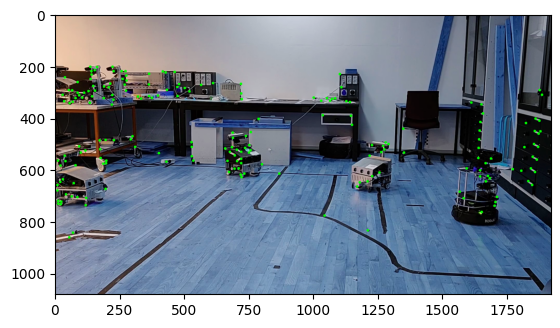

In [ ]:
# Shows up to 200 points in a single frame of the robot video
cap = cv2.VideoCapture('Robots.mp4')                       

ret, frame = cap.read()
cap.release()

# Change image to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

corners = cv2.goodFeaturesToTrack(gray,200,0.1,10)
corners = np.int0(corners) #opencv version 4.12.0 windows
# corners = np.intp(corners) #opencv version 5.0.0 macos

# Iterate over the corners and draw a circle at that location
for i in corners:
    x,y = i.ravel()
    cv2.circle(frame,(x,y),5,(0,255,0),-1)


# Display image
plt.imshow(frame)

In [2]:
cap = cv2.VideoCapture('../data/Robots.mp4')                       

ret, frame1 = cap.read()
gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)

### PRESS Q TO CANCEL THE VIDEO STREAM ###
while ret:
    gray2 = gray1
    ret, frame1 = cap.read()

    if not ret:
        break

    gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
    feat1 = cv2.goodFeaturesToTrack(gray1,200,0.1,10)

    feat2, status, error = cv2.calcOpticalFlowPyrLK(gray2, gray1, feat1, None)

    for i in range(len(feat1)):
        f10=int(feat1[i][0][0])
        f11=int(feat1[i][0][1])
        f20=int(feat2[i][0][0])
        f21=int(feat2[i][0][1])

        distance = np.linalg.norm(feat1[i] - feat2[i])
        
        #Only draw the flow lines and points if the movement is more than 5 pixels
        if distance < 5:
            continue
        cv2.line(frame1, (f10,f11), (f20, f21), (0, 255, 0), 2)
        cv2.circle(frame1, (f10, f11), 5, (0, 255, 0), -1)

    cv2.imshow("stream",frame1)
    key = cv2.waitKey(20)
    if key==ord('q'):
        break

cv2.destroyAllWindows()
cap.release()

In [ ]:
#2nd version
cap = cv2.VideoCapture('Robots.mp4')

ret, img = cap.read()
corners = None
gray1 = None
if ret:
    gray1 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    corners = cv2.goodFeaturesToTrack(gray1, 50, 0.01, minDistance=50)
    
    for i in corners:
        x, y = i.ravel()
        cv2.circle(img, (int(x), int(y)), 10, (0, 255, 0), -1)

    cv2.imshow("Image", img)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray2 = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    new_corners, status, error = cv2.calcOpticalFlowPyrLK(gray1, gray2, corners, None)

    good = status.ravel() == 1
    old_pts = corners[good]
    new_pts = new_corners[good]

    MOVE_THRESHOLD = 2.0
    for i in range(len(new_pts)):
        x_old, y_old = old_pts[i][0]
        x_new, y_new = new_pts[i][0]
        dist = np.hypot(x_new - x_old, y_new - y_old)
        if dist > MOVE_THRESHOLD:
            cv2.circle(frame, (int(x_new), int(y_new)), 10, (0, 255, 0), -1)

    corners = np.array(new_pts, dtype=np.float32)

    gray1 = gray2

    cv2.imshow("Video", frame)
    if cv2.waitKey(25) & 0xFF==ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Dense optical flow.
The code for dense optical flow runs a little slow on my laptop CPU. The video looks ok, but because of CPU speed the framerate drops to around 5 fps, which is ok but also a little ugly. If we had time and motivation we could make the video run on GPU. I think the most of the calculations are sequential so running on multiple cores is not really possible.

In [2]:
cap = cv2.VideoCapture('Robots.mp4')                       

ret, frame1 = cap.read()
gray1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)

while ret:
    gray2 = gray1
    ret, frame1 = cap.read()

    if not ret:
        break

    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        gray2, gray1, None,
        0.5, 3, 15, 3, 5, 1.5, 0
    )

    distance = np.linalg.norm(flow, axis=2)

    #Step is how many pixels to move in the video before checking to draw a new arrow
    step = 40

    for y in range(0, gray1.shape[0], step):
        for x in range(0, gray1.shape[1], step):

            dx, dy = flow[y, x]
            #Only draw the flow vector if the movement is more than 5 pixels
            if distance[y, x] < 5:
                continue

            cv2.arrowedLine(
                frame1,
                (x, y),
                (int(x + dx), int(y + dy)),
                (0, 255, 0),
                2,
                tipLength=0.5
            )

    cv2.imshow("stream", frame1)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()
cap.release()

Dense optical flow with colors.
Same Farneback flow as above, just drawn as colors instead of arrows. The hue is the direction the pixel moves and the brightness is how fast, so anything standing still stays black.
Scaling the frame down before Farneback fixes the framerate problem from above, full resolution is around 4 fps and half is around 16.
The brightness uses a fixed divider instead of cv2.normalize, because normalize rescales every frame to its own maximum and that makes the video flicker.

In [ ]:
SCALE   = 0.5     # shrink the frame before Farneback, full res runs at about 4 fps
MAG_MAX = 8.0     # movement in pixels that shows up as full brightness

cap = cv2.VideoCapture('Robots.mp4')

ret, frame1 = cap.read()
gray1 = cv2.cvtColor(cv2.resize(frame1, None, fx=SCALE, fy=SCALE), cv2.COLOR_BGR2GRAY)

# hsv image the same size as the scaled down frame, saturation is always full
hsv = np.zeros((*gray1.shape, 3), np.uint8)
hsv[..., 1] = 255

### PRESS Q TO CANCEL THE VIDEO STREAM ###
while ret:
    gray2 = gray1
    ret, frame1 = cap.read()

    if not ret:
        break

    small = cv2.resize(frame1, None, fx=SCALE, fy=SCALE)
    gray1 = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        gray2, gray1, None,
        0.5, 3, 15, 3, 5, 1.2, 0
    )

    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # hue is the direction, value is the speed
    hsv[..., 0] = ang * 90 / np.pi
    hsv[..., 2] = np.clip(mag * 255 / MAG_MAX, 0, 255)

    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # original on the left, flow colors on the right
    cv2.imshow("stream", np.hstack([small, bgr]))

    key = cv2.waitKey(25) & 0xFF
    if key == ord('q') or key == ord('Q'):
        break

cv2.destroyAllWindows()
cap.release()

Challenge code
First function draw_rectangle is taken from AI (Claude). This function serve different mouse events, it is used to draw rectangle over robots which we want to track. Next part is looking for good features to track and display each of them at the picture. At this point system waits for user input which is to draw rectangle over points to track. After choosing points, the rest is filtered by mask which bounds them to the size of the rectangle. Sparse optical flow is used for tracking points. Except for points system can draw lines of robot movement to do that change DRAW_LINES flag. 
There are some issues with "hand over" of points, if the robot crosses paths with another moving robot then some points are in some cases transferred to the other the moving robot, and the points are not tracked as they move on this other robot. The fix to this is a stronger description of the points, meaning each point needs to be more uniquely described so we can better find the same point again. We did however not have time to implement this improvement of the challenge code.

REMEMBER: Draw rectangle from top left corner 

In [2]:
FILE_PATH = "../data/Robots.mp4"
DRAW_LINES = False

drawing = False
ix, iy = -1,-1
rect = None

def draw_rectangle(event, x, y, flags, param):
    global ix, iy, drawing, rect, img_display

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        ix, iy = x,y

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            img_display = img.copy()
            cv2.rectangle(img_display, (ix, iy), (x,y), (0,255,0), 2)

    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        x1, y1 = min(ix, x), min(iy, y)
        x2, y2 = max(ix, x), max(iy, y)
        rect = (x1, y1, x2, y2)
        img_display = img.copy()
        cv2.rectangle(img_display, (ix, iy), (x,y), (0,255,0), 2)

cap = cv2.VideoCapture(FILE_PATH)
ret, img = cap.read()

x1, y1, x2, y2 = -1,-1,-1,-1
corners = None
gray1 = None
if ret:
    gray1 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    corners = cv2.goodFeaturesToTrack(gray1, 200, 0.01, minDistance=10)


    for i in corners:
        x, y = i.ravel()
        cv2.circle(img, (int(x), int(y)), 10, (0, 255, 0), -1)

    img_display = img.copy()
    cv2.namedWindow("Image")
    cv2.setMouseCallback("Image", draw_rectangle)
    while True:
        cv2.imshow("Image", img_display)
        if drawing == False and rect:
            x1, y1, x2, y2 = rect
            break

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break

    cv2.destroyAllWindows()
    pts = corners.reshape(-1, 2)
    mask = (pts[:, 0] >= x1) & (pts[:, 1] >= y1) &\
        (pts[:, 0] <= x2) & (pts[:, 1] <= y2)

    corners = corners[mask] 

trail_mask = np.zeros_like(img)
while True:
    ret, frame = cap.read()

    if not ret:
        break

    gray2 = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    new_corners, status, error = cv2.calcOpticalFlowPyrLK(gray1, gray2, corners, None)

    good = status.ravel() == 1
    old_pts = corners[good]
    new_pts = new_corners[good]

    MOVE_THRESHOLD = 2.0
    for i in range(len(new_pts)):
        x_old, y_old = old_pts[i][0]
        x_new, y_new = new_pts[i][0]
        dist = np.hypot(x_new - x_old, y_new - y_old)
        if DRAW_LINES:
            cv2.line(trail_mask, (int(x_old), int(y_old)), (int(x_new), int(y_new)), (0, 255, 0), 2)
        if dist > MOVE_THRESHOLD:
            cv2.circle(frame, (int(x_new), int(y_new)), 10, (0, 255, 0), -1)

    corners = np.array(new_pts, dtype=np.float32)

    gray1 = gray2
    result = cv2.add(frame, trail_mask)
    cv2.imshow("Video", result)
    if cv2.waitKey(25) & 0xFF==ord('q'):
        break

cap.release()
cv2.destroyAllWindows()